In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, smooth_data, merge_datasets, slice_by_dates

### Data preparation

In [3]:
# North site
insitu_df1 = load_and_prepare_data('../data/processed/in-situ/SDH1_daily-insitu-data.csv')
insitu_df1 = handle_duplicate_values(insitu_df1)
insitu_df1 = reindex_daily(insitu_df1)

# South site
insitu_df2 = load_and_prepare_data('../data/processed/in-situ/SDH2_daily-insitu-data.csv')
insitu_df2 = handle_duplicate_values(insitu_df2)
insitu_df2 = reindex_daily(insitu_df2)

### Plots

Pozos sitio norte + precipitaciones

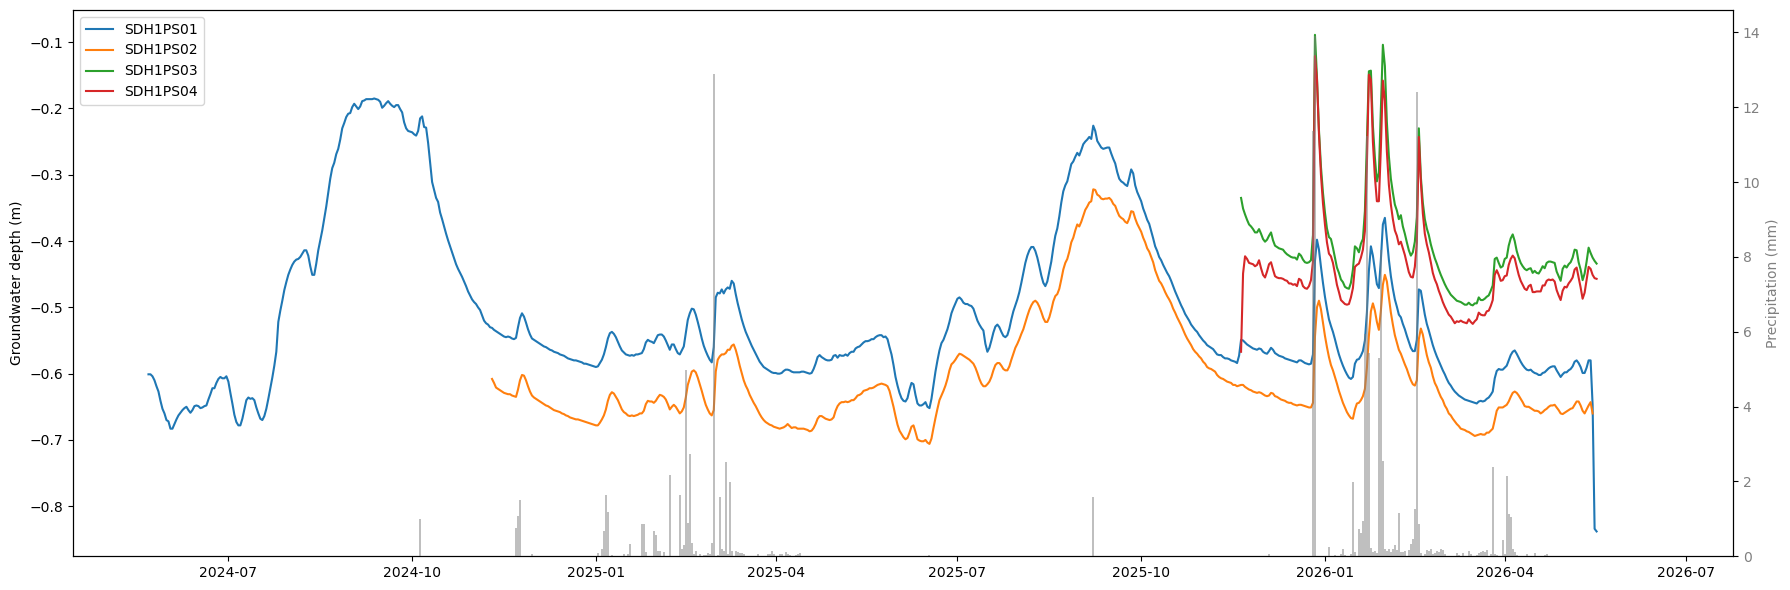

In [4]:
# Extract gw depth data
wells1 = insitu_df1[['SDH1PS01_gw-depth_m', 'SDH1PS02_gw-depth_m', 'SDH1PS03_gw-depth_m', 'SDH1PS04_gw-depth_m']]

# Extract precipitation data
precipitation1 = insitu_df1['ATMOS41_precipitation_mm']

# Figure
fig, ax1 = plt.subplots(figsize=(18, 6))

# Configure primary y axis
ax1.plot(wells1.index, wells1['SDH1PS01_gw-depth_m'], label='SDH1PS01')
ax1.plot(wells1.index, wells1['SDH1PS02_gw-depth_m'], label='SDH1PS02')
ax1.plot(wells1.index, wells1['SDH1PS03_gw-depth_m'], label='SDH1PS03')
ax1.plot(wells1.index, wells1['SDH1PS04_gw-depth_m'], label='SDH1PS04')

ax1.set_ylabel('Groundwater depth (m)')
ax1.legend(loc='upper left')

# Configure secondary y axis
ax2 = ax1.twinx()
ax2.bar(precipitation1.index, precipitation1, width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Pozos sitio norte (altitud) + precipitaciones

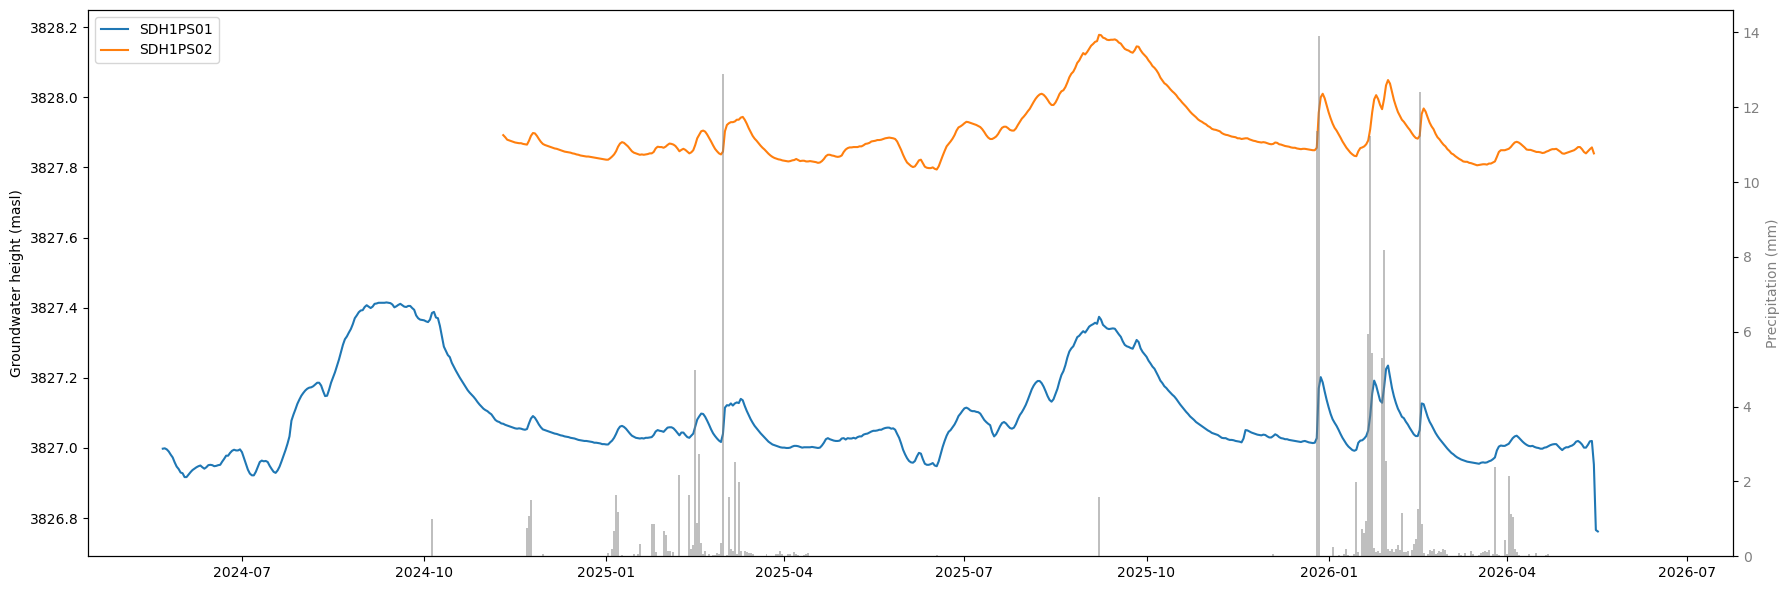

In [5]:
# Extract gw level data
wells1 = insitu_df1[['SDH1PS01_gw-level_masl', 'SDH1PS02_gw-level_masl']]

# Extract precipitation data
precipitation1 = insitu_df1['ATMOS41_precipitation_mm']

# Figure
fig, ax1 = plt.subplots(figsize=(18, 6))

# Configure primary y axis
ax1.plot(wells1.index, wells1['SDH1PS01_gw-level_masl'], label='SDH1PS01')
ax1.plot(wells1.index, wells1['SDH1PS02_gw-level_masl'], label='SDH1PS02')

ax1.set_ylabel('Groundwater height (masl)')
ax1.legend(loc='upper left')

# Configure secondary y axis
ax2 = ax1.twinx()
ax2.bar(precipitation1.index, precipitation1, width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Pozos sitio sur + precipitaciones

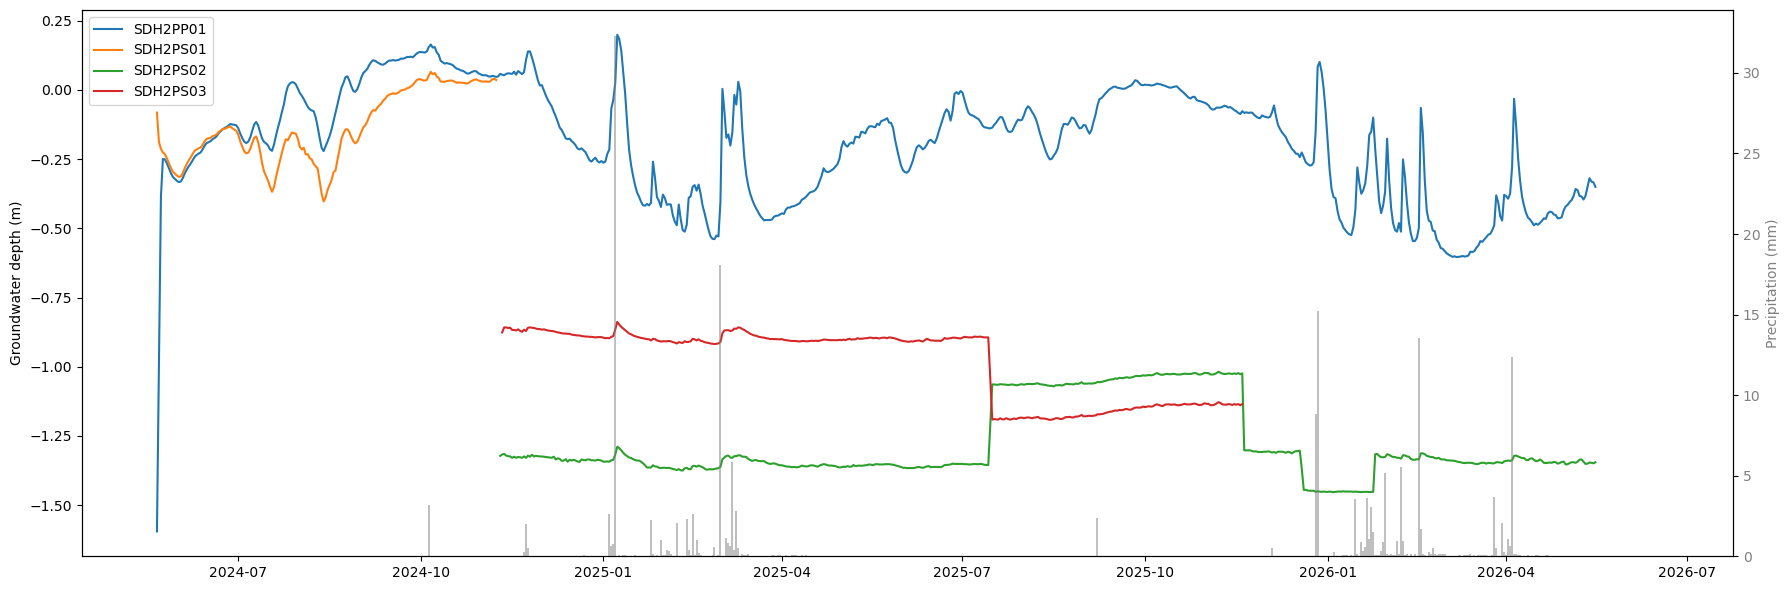

In [6]:
# Extract gw depth data
wells2 = insitu_df2[['SDH2PP01_gw-depth_m', 'SDH2PS01_gw-depth_m', 'SDH2PS02_gw-depth_m', 'SDH2PS03_gw-depth_m']]

# Extract precipitation data
precipitation2 = insitu_df2['ATMOS41_precipitation_mm']

# Figure
fig, ax1 = plt.subplots(figsize=(18, 6))

# Configure primary y axis
ax1.plot(wells2.index, wells2['SDH2PP01_gw-depth_m'], label='SDH2PP01')
ax1.plot(wells2.index, wells2['SDH2PS01_gw-depth_m'], label='SDH2PS01')
ax1.plot(wells2.index, wells2['SDH2PS02_gw-depth_m'], label='SDH2PS02')
ax1.plot(wells2.index, wells2['SDH2PS03_gw-depth_m'], label='SDH2PS03')

ax1.set_ylabel('Groundwater depth (m)')
ax1.legend(loc='upper left')

# Configure secondary y axis
ax2 = ax1.twinx()
ax2.bar(precipitation2.index, precipitation2, width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

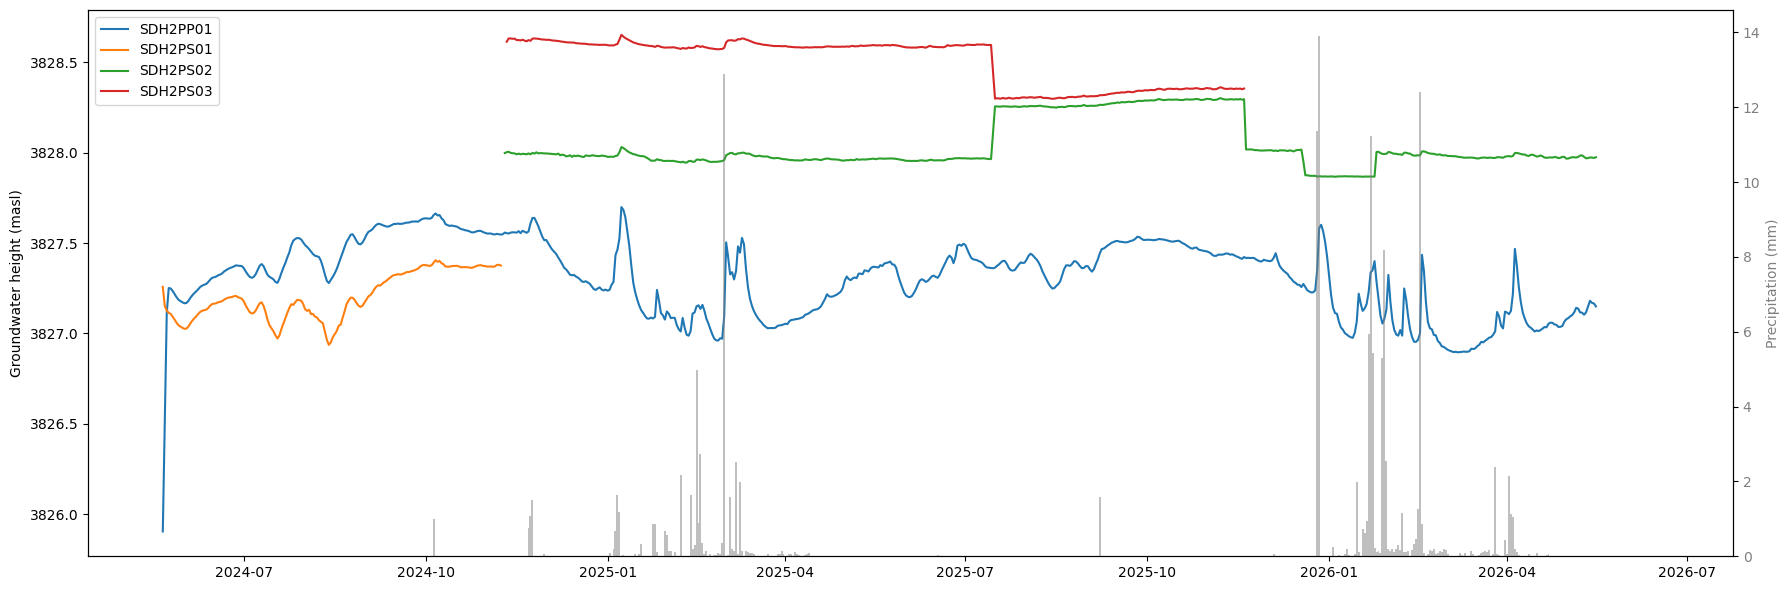

In [7]:
# Extract gw level data
wells2 = insitu_df2[['SDH2PP01_gw-level_masl', 'SDH2PS01_gw-level_masl', 'SDH2PS02_gw-level_masl', 'SDH2PS03_gw-level_masl']]

# Extract precipitation data
precipitation2 = insitu_df2['ATMOS41_precipitation_mm']

# Figure
fig, ax1 = plt.subplots(figsize=(18, 6))

# Configure primary y axis
ax1.plot(wells2.index, wells2['SDH2PP01_gw-level_masl'], label='SDH2PP01')
ax1.plot(wells2.index, wells2['SDH2PS01_gw-level_masl'], label='SDH2PS01')
ax1.plot(wells2.index, wells2['SDH2PS02_gw-level_masl'], label='SDH2PS02')
ax1.plot(wells2.index, wells2['SDH2PS03_gw-level_masl'], label='SDH2PS03')

ax1.set_ylabel('Groundwater height (masl)')
ax1.legend(loc='upper left')

# Configure secondary y axis
ax2 = ax1.twinx()
ax2.bar(precipitation1.index, precipitation1, width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()